# Post Image Processing of B-mode Ultrasound Images
**Darshil Maniya (262SP009)** · M.Tech SPML, NITK Surathkal · NITK-UsoundSim team

Input: a raw grayscale B-mode image from the scanner. Output: a clean image with speckle removed,
edges kept and good contrast. Image formation (beamforming, envelope, log compression, scan conversion)
is out of scope here. Classical image processing only.

In [1]:
# Colab setup (kagglehub, OpenCV, scikit-image, SciPy and matplotlib are already in Colab; bm3d also installs PyWavelets)
%pip install -q kagglehub bm3d

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, glob, random, shutil, zipfile, io, time
from pathlib import Path
import numpy as np, cv2, requests, kagglehub
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED); np.random.seed(SEED)
IN_COLAB = 'google.colab' in str(get_ipython())
DATA = Path('/content/data' if IN_COLAB else 'data'); DATA.mkdir(parents=True, exist_ok=True)
N_PER_ORGAN, MAX_SIDE = 20, 512
ORGANS = ['breast', 'thyroid', 'kidney', 'liver']

/Users/darshil/Documents/262SP009-Post-Image-Processing/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data loading
| Organ | Dataset | Masks | Automatic download? |
|---|---|---|---|
| Breast | BUSI (Kaggle `aryashah2k/breast-ultrasound-images-dataset`) | lesion | yes, kagglehub works without login |
| Thyroid | TN3K (Kaggle mirror `tjahan/tn3k-thyroid-nodule-region-segmentation-dataset`) | nodule | yes, kagglehub works without login |
| Kidney | Open Kidney Ultrasound Data Set | kidney capsule | **images need registration**; masks are public on GitHub |
| Liver | Annotated Ultrasound Liver images (Zenodo 10.5281/zenodo.7272660) | mass polygons | yes, direct Zenodo links |

No usable image data for thyroid was found on Zenodo (search returned only papers), so TN3K is used.
Kidney fallback: without the uploaded images we use the public Kaggle set `zaynebnouiri/renal-data`
(real kidney B-mode scans, **no masks**).

In [3]:
def fetch(url, dest, tries=3):
    dest, part = Path(dest), Path(str(dest) + '.part')
    for t in range(tries):
        if dest.exists(): break
        try:                                                        # stream to .part, rename when complete
            with requests.get(url, stream=True, timeout=(30, 60)) as r:
                r.raise_for_status()
                with open(part, 'wb') as fh:
                    for chunk in r.iter_content(1 << 20): fh.write(chunk)
            part.rename(dest)
        except requests.RequestException as e:
            print(f'download attempt {t + 1} failed: {e}')
    if not dest.exists(): raise RuntimeError(f'could not download {url}')
    return dest

def unzip_once(zpath, out):
    if not Path(out).exists(): shutil.unpack_archive(str(zpath), str(out))
    return Path(out)

def to_gray(img):
    return img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def resize_max(img, mask=None, max_side=MAX_SIDE):
    s = max_side / max(img.shape[:2])
    if s >= 1: return img, mask
    size = (round(img.shape[1] * s), round(img.shape[0] * s))
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    if mask is not None:
        mask = cv2.resize(mask.astype(np.uint8), size, interpolation=cv2.INTER_NEAREST).astype(bool)
    return img, mask

def polygon_mask(points, shape):
    m = np.zeros(shape, np.uint8)
    polys = [points] if np.ndim(points[0]) == 1 else points       # one polygon or a list of them
    for p in polys: cv2.fillPoly(m, [np.round(np.array(p)).astype(np.int32)], 1)
    return m.astype(bool)

**Kidney images (manual step).** The Open Kidney images need a free registration:
1. Fill the form at https://ubc.ca1.qualtrics.com/jfe/form/SV_1TfBnLm1wwZ9srk (see https://rsingla.ca/kidneyUS/).
2. After approval, download the images and either copy the folder to `data/kidney/images/`,
   or in Colab set `UPLOAD_KIDNEY = True` and upload the zip.

If no images are found, the notebook continues with the fallback kidney set (no masks).

In [4]:
UPLOAD_KIDNEY = False
KIDNEY_IMG_DIR = DATA / 'kidney' / 'images'
if UPLOAD_KIDNEY and IN_COLAB:
    from google.colab import files
    for fn in files.upload(): shutil.unpack_archive(fn, KIDNEY_IMG_DIR)

In [5]:
def list_breast():
    root = Path(kagglehub.dataset_download('aryashah2k/breast-ultrasound-images-dataset')) / 'Dataset_BUSI_with_GT'
    items = []
    for f in sorted(glob.glob(str(root / '*' / '*).png'))):                # benign/malignant/normal images
        masks = sorted(glob.glob(f[:-4] + '_mask*.png'))
        items.append((f, lambda sh, m=masks: np.any([cv2.imread(x, 0) > 127 for x in m], axis=0)))
    return items

def list_thyroid():
    root = Path(kagglehub.dataset_download('tjahan/tn3k-thyroid-nodule-region-segmentation-dataset'))
    return [(f, lambda sh, f=f: cv2.imread(f.replace('test-image', 'test-mask'), 0) > 127)
            for f in sorted(glob.glob(str(root / 'test-image' / '*.jpg')))]

def list_liver():
    items = []
    for cls in ['Benign', 'Malignant']:
        z = fetch(f'https://zenodo.org/api/records/7272660/files/{cls}.zip/content', DATA / f'liver_{cls}.zip')
        root = unzip_once(z, DATA / 'liver' / cls) / cls
        for f in sorted(glob.glob(str(root / 'image' / '*.jpg'))):
            js = root / 'segmentation' / 'mass' / (Path(f).stem + '.json')
            items.append((f, lambda sh, js=js: polygon_mask(json.load(open(js)), sh)))
    return items

def list_kidney():
    imgs = sorted(p for p in KIDNEY_IMG_DIR.rglob('*') if p.suffix.lower() in ('.png', '.jpg', '.jpeg'))
    if imgs:                                                         # Open Kidney + public capsule masks
        z = fetch('https://codeload.github.com/rsingla92/kidneyUS/zip/refs/heads/main', DATA / 'kidneyUS.zip')
        mdir = unzip_once(z, DATA / 'kidneyUS') / 'kidneyUS-main' / 'labels' / 'reviewed_masks_1' / 'capsule'
        return [(str(p), lambda sh, m=mdir / (p.stem + '.png'): cv2.imread(str(m), 0) > 0)
                for p in imgs if (mdir / (p.stem + '.png')).exists()]
    print('kidney: Open Kidney images not found -> using fallback Kaggle renal-data (no masks)')
    root = Path(kagglehub.dataset_download('zaynebnouiri/renal-data'))
    return [(f, None) for f in sorted(glob.glob(str(root / 'images' / '*' / '*.jpg')))]

LISTERS = {'breast': list_breast, 'thyroid': list_thyroid, 'kidney': list_kidney, 'liver': list_liver}

def load_dataset(organ, n=N_PER_ORGAN, seed=SEED):
    items = LISTERS[organ]()
    if any(m is not None for _, m in items):                         # prefer images with a non-empty mask
        items = [it for it in items if it[1] is not None]
    rng = np.random.default_rng(seed)
    data = []
    for i in rng.permutation(len(items)):
        f, get_mask = items[i]
        img = to_gray(cv2.imread(f))
        mask = get_mask(img.shape) if get_mask else None
        if mask is not None and (mask.shape != img.shape or not mask.any()): continue
        img, mask = resize_max(img, mask)
        data.append({'image': img, 'mask': mask, 'name': f'{organ}/{Path(f).name}'})
        if len(data) == n: break
    return data

In [6]:
datasets = {}
for organ in ORGANS:
    try:
        datasets[organ] = load_dataset(organ)
    except Exception as e:
        print(f'{organ}: FAILED -> {type(e).__name__}: {e}'); datasets[organ] = []

for organ, d in datasets.items():
    n_mask = sum(x['mask'] is not None for x in d)
    sizes = [x['image'].shape for x in d]
    print(f'{organ:8s} images: {len(d):2d}  masks: {n_mask:2d}  '
          f'size range: {min(sizes) if sizes else "-"} .. {max(sizes) if sizes else "-"}')

kidney: Open Kidney images not found -> using fallback Kaggle renal-data (no masks)


breast   images: 20  masks: 20  size range: (339, 512) .. (512, 487)
thyroid  images: 20  masks: 20  size range: (302, 413) .. (512, 495)
kidney   images: 20  masks:  0  size range: (398, 512) .. (403, 512)
liver    images: 20  masks: 20  size range: (378, 512) .. (422, 512)


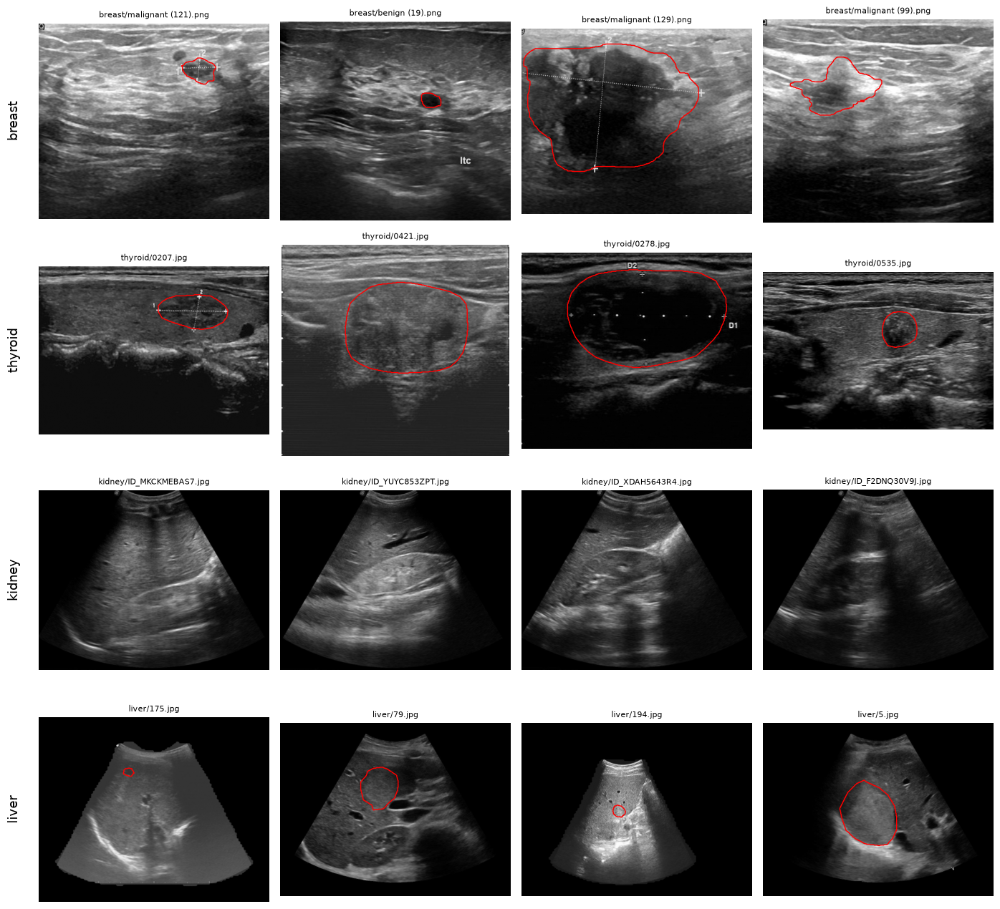

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(14, 13))
for r, organ in enumerate(ORGANS):
    for c in range(4):
        ax = axes[r, c]; ax.axis('off')
        if c >= len(datasets[organ]): continue
        s = datasets[organ][c]
        ax.imshow(s['image'], cmap='gray', vmin=0, vmax=255)
        if s['mask'] is not None: ax.contour(s['mask'], [0.5], colors='r', linewidths=1)
        ax.set_title(s['name'], fontsize=8)
    axes[r, 0].text(-0.08, 0.5, organ, transform=axes[r, 0].transAxes, rotation=90,
                    va='center', ha='right', fontsize=13)
plt.tight_layout(); plt.show()

## 2. Preprocessing
- `auto_mask`: scan area = convex hull of all large non-black regions (works for fans and rectangles).
- `find_annotations`: burned-in text, calipers, rulers and arrows are bright **and have 1-pixel sharp edges**
  (large Laplacian), while bright tissue (fascia, skin line, speckle) is smooth. Seeds = very sharp bright pixels;
  a bright blob is kept only if at least half of it is next to a seed. Only searched inside the scan area.
- `clean_annotations`: inpaint the detected marks (`cv2.inpaint`, Telea).
- `normalize`: percentile stretch (0.5-99.5 %) to 0-255 inside the scan mask, 0 outside.

In [8]:
def auto_mask(img, t=3, min_frac=0.01):
    m = (cv2.blur(img, (9, 9)) > t).astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((7, 7), np.uint8))
    n, lab, st, _ = cv2.connectedComponentsWithStats(m)
    big = [i for i in range(1, n) if st[i, cv2.CC_STAT_AREA] > min_frac * img.size]
    if not big: return np.ones(img.shape, bool)
    hull = cv2.convexHull(cv2.findNonZero(np.isin(lab, big).astype(np.uint8)))
    out = np.zeros(img.shape, np.uint8); cv2.fillPoly(out, [hull], 1)
    return cv2.erode(out, np.ones((5, 5), np.uint8)) > 0

def find_annotations(img, scan=None, lap_t=150, int_t=180, ratio_t=0.5):
    f = img.astype(np.float32)
    diff = f - cv2.medianBlur(img, 15)                                # brightness above local background
    lap = np.abs(cv2.Laplacian(f, cv2.CV_32F, ksize=1))              # edge sharpness
    cand = ((diff > 40) & (img > 120)).astype(np.uint8)
    seed = (lap > lap_t) & (diff > 60) & (img > int_t)
    if scan is not None: seed &= cv2.erode(scan.astype(np.uint8), np.ones((15, 15), np.uint8)) > 0
    near = cv2.dilate(seed.astype(np.uint8), np.ones((3, 3), np.uint8)) > 0
    n, lab = cv2.connectedComponents(cand, connectivity=8)
    ratio = np.bincount(lab[near], minlength=n) / np.maximum(np.bincount(lab.ravel(), minlength=n), 1)
    keep = np.flatnonzero(ratio >= ratio_t); keep = keep[keep > 0]
    return cv2.dilate(np.isin(lab, keep).astype(np.uint8), np.ones((3, 3), np.uint8)) > 0

def clean_annotations(img, scan=None):
    marks = find_annotations(img, scan)
    return cv2.inpaint(img, marks.astype(np.uint8), 3, cv2.INPAINT_TELEA), marks

def normalize(img, mask, lo=0.5, hi=99.5):
    a, b = np.percentile(img[mask], [lo, hi])
    out = np.clip((img.astype(np.float32) - a) * 255 / max(b - a, 1), 0, 255).astype(np.uint8)
    out[~mask] = 0
    return out

def prepare(img):
    scan = auto_mask(img)
    clean, _ = clean_annotations(img, scan)
    return normalize(clean, scan), scan

In [9]:
for organ in ORGANS:
    for s in datasets[organ]:
        s['clean'], s['scan'] = prepare(s['image'])
        s['marks'] = find_annotations(s['image'], s['scan'])

print('organ    removed px % (mean / max)   lesion px removed %   lesion outside scan %   scan area %')
for organ in ORGANS:
    d = datasets[organ]
    rem = [100 * s['marks'].mean() for s in d]
    les = [100 * (s['marks'] & s['mask']).sum() / s['mask'].sum() for s in d if s['mask'] is not None]
    out = [100 * (s['mask'] & ~s['scan']).sum() / s['mask'].sum() for s in d if s['mask'] is not None]
    area = [100 * s['scan'].mean() for s in d]
    fmt = lambda v: f'{np.mean(v):6.2f} / {np.max(v):5.2f}' if v else '     n/a      '
    print(f'{organ:8s} {fmt(rem):>22s}   {fmt(les):>18s}   {fmt(out):>18s}   {np.mean(area):6.1f}')

organ    removed px % (mean / max)   lesion px removed %   lesion outside scan %   scan area %
breast             0.24 /  1.49         1.73 / 10.34         0.00 /  0.00     99.3
thyroid            0.11 /  0.49         0.71 /  6.88         0.00 /  0.00     90.5
kidney             0.00 /  0.00            n/a                  n/a           63.0
liver              0.02 /  0.12         0.08 /  1.64         0.00 /  0.00     43.1


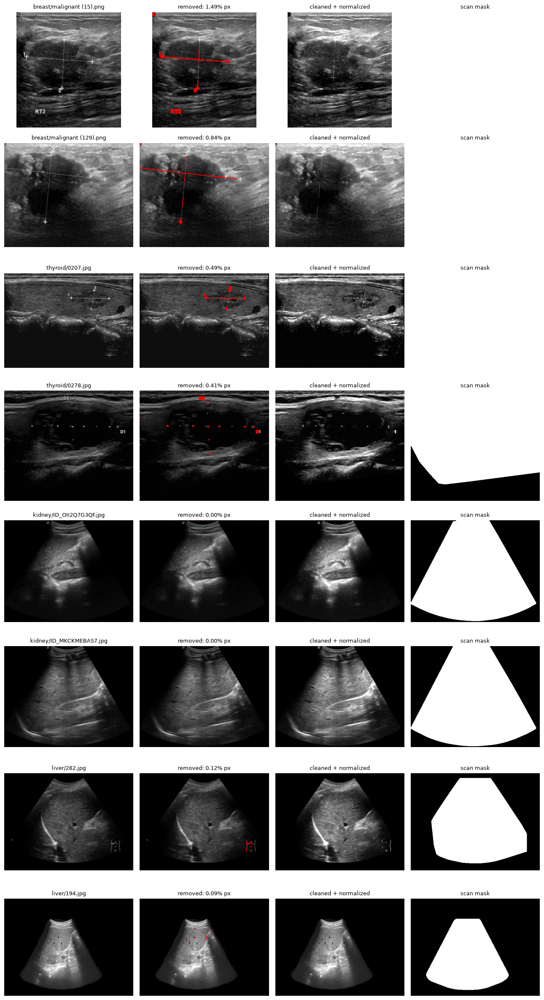

In [10]:
show = [s for organ in ORGANS for s in sorted(datasets[organ], key=lambda s: -s['marks'].sum())[:2]]
fig, axes = plt.subplots(len(show), 4, figsize=(13, 3 * len(show)))
for row, s in zip(axes, show):
    over = np.dstack([s['image']] * 3); over[s['marks']] = (255, 0, 0)
    for ax, im, t in zip(row, [s['image'], over, s['clean'], s['scan'] * 255],
                         [s['name'], f"removed: {100 * s['marks'].mean():.2f}% px", 'cleaned + normalized', 'scan mask']):
        ax.imshow(im, cmap='gray', vmin=0, vmax=255); ax.set_title(t, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## 3. Quality metrics
No clean reference exists, so all metrics are no-reference or use the lesion mask.
- **ENL** = mean² / variance in a homogeneous background ROI (higher = smoother speckle).
- **Speckle index (SI)** = mean of local std / local mean (7×7) inside the scan area (lower = less speckle).
- **CNR** = |μ_lesion − μ_ring| / sqrt(σ²_lesion + σ²_ring); ring = lesion dilated by 10 px minus lesion, inside the scan.
- **gCNR** = 1 − overlap of the lesion and ring histograms (0 = identical, 1 = fully separable).
- **Edge** = mean Sobel gradient magnitude on a 3-px band across the lesion border (higher = sharper).
- **Runtime** in ms (`timed`).

`auto_background_roi` picks the 31×31 window with the least *anatomical structure* (lowest std of the 9×9-smoothed
image / mean) inside the scan area, away from the lesion, not in dark shadow (mean above the 25th percentile) and
not in flat padding or artificial smooth fill (less than half of its pixels within 1 grey level of both neighbours). It is chosen **once on the original image**
and reused for every processed version, so ENL is always measured on the same tissue.

In [11]:
RING, ROI_SIZE = 10, 31
kernel = lambda k: cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))

def timed(fn, *args, **kw):
    t0 = time.perf_counter(); out = fn(*args, **kw)
    return out, 1000 * (time.perf_counter() - t0)

def enl(img, roi):
    v = img[roi].astype(np.float64)
    return v.mean() ** 2 / max(v.var(), 1e-9)

def speckle_index(img, scan_mask, k=7):
    f = img.astype(np.float32)
    mu = cv2.blur(f, (k, k)); sd = np.sqrt(np.maximum(cv2.blur(f * f, (k, k)) - mu * mu, 0))
    valid = (cv2.erode(scan_mask.astype(np.uint8), kernel(k)) > 0) & (mu > 1)
    return float(np.mean(sd[valid] / mu[valid]))

def lesion_ring(lesion_mask, scan_mask=None):
    ring = (cv2.dilate(lesion_mask.astype(np.uint8), kernel(2 * RING + 1)) > 0) & ~lesion_mask
    return ring & scan_mask if scan_mask is not None else ring

def cnr(img, lesion_mask, scan_mask=None):
    a, b = img[lesion_mask].astype(np.float64), img[lesion_ring(lesion_mask, scan_mask)].astype(np.float64)
    return abs(a.mean() - b.mean()) / np.sqrt(a.var() + b.var() + 1e-9)

def gcnr(img, lesion_mask, scan_mask=None):
    a, b = img[lesion_mask], img[lesion_ring(lesion_mask, scan_mask)]
    ha = np.bincount(a, minlength=256) / a.size; hb = np.bincount(b, minlength=256) / b.size
    return 1 - np.minimum(ha, hb).sum()

def edge_sharpness(img, lesion_mask):
    f = img.astype(np.float32)
    g = np.hypot(cv2.Sobel(f, cv2.CV_32F, 1, 0), cv2.Sobel(f, cv2.CV_32F, 0, 1))
    m = lesion_mask.astype(np.uint8)
    band = cv2.dilate(m, kernel(3)) != cv2.erode(m, kernel(3))
    return float(g[band].mean())

def auto_background_roi(img, scan_mask, lesion_mask=None, w=ROI_SIZE):
    f = img.astype(np.float32)
    local_stats = lambda x: (cv2.blur(x, (w, w)), np.sqrt(np.maximum(cv2.blur(x * x, (w, w)) - cv2.blur(x, (w, w)) ** 2, 0)))
    mu, _ = local_stats(f)
    _, structure = local_stats(cv2.blur(f, (9, 9)))                   # variation left after smoothing = anatomy
    base = cv2.erode(scan_mask.astype(np.uint8), np.ones((w + 2, w + 2), np.uint8)) > 0
    base[:w, :] = base[-w:, :] = base[:, :w] = base[:, -w:] = False  # whole window inside the image
    flat = np.zeros(img.shape, np.float32)                            # pixel within 1 grey level of right/lower neighbour
    flat[:-1, :-1] = (np.abs(f[:-1, :-1] - f[1:, :-1]) <= 1) & (np.abs(f[:-1, :-1] - f[:-1, 1:]) <= 1)
    base &= (mu > np.percentile(f[scan_mask], 25)) & (cv2.blur(flat, (w, w)) < 0.5)   # no shadow, no flat padding
    for margin in (2 * w, w, w // 2, 0):                              # relax lesion distance if nothing is left
        ok = base.copy()
        if lesion_mask is not None and margin: ok &= cv2.dilate(lesion_mask.astype(np.uint8), kernel(2 * margin + 1)) == 0
        if ok.any(): break
    y, x = np.unravel_index(np.argmin(np.where(ok, structure / np.maximum(mu, 1), np.inf)), mu.shape)
    roi = np.zeros(img.shape, bool); roi[y - w // 2: y + w // 2 + 1, x - w // 2: x + w // 2 + 1] = True
    return roi

def metrics(img, s, ms=np.nan):
    r = {'ENL': enl(img, s['roi']), 'SI': speckle_index(img, s['scan']), 'ms': ms}
    if s['mask'] is not None:
        r.update(CNR=cnr(img, s['mask'], s['scan']), gCNR=gcnr(img, s['mask'], s['scan']),
                 Edge=edge_sharpness(img, s['mask']))
    return r

In [12]:
METRICS = ['ENL', 'SI', 'CNR', 'gCNR', 'Edge', 'ms']

def table(rows, title):
    print(title); print(f"{'organ':8s} {'input':10s}" + ''.join(f'{m:>16s}' for m in METRICS))
    for (organ, name), res in rows.items():
        cells = []
        for m in METRICS:
            v = np.array([r[m] for r in res if m in r and np.isfinite(r[m])])
            cells.append(f'{v.mean():7.2f} ± {v.std():5.2f}' if v.size else 'n/a')
        print(f'{organ:8s} {name:10s}' + ''.join(f'{c:>16s}' for c in cells))

baseline = {}
for organ in ORGANS:
    for s in datasets[organ]:
        (s['clean'], s['scan']), ms = timed(prepare, s['image'])
        s['roi'] = auto_background_roi(s['image'], s['scan'], s['mask'])
        s['base'] = metrics(s['clean'], s, ms)
        baseline.setdefault((organ, 'original'), []).append(metrics(s['image'], s))
        baseline.setdefault((organ, 'prepared'), []).append(s['base'])
table(baseline, 'Baseline (no despeckling). ms = prepare() time per image. Mean ± std over 20 images.')

Baseline (no despeckling). ms = prepare() time per image. Mean ± std over 20 images.
organ    input                  ENL              SI             CNR            gCNR            Edge              ms
breast   original   175.72 ± 128.75    0.18 ±  0.07    0.99 ±  0.36    0.57 ±  0.14   85.57 ± 30.83             n/a
breast   prepared   155.24 ± 102.91    0.21 ±  0.06    1.01 ±  0.36    0.58 ±  0.14   97.81 ± 34.26   21.62 ±  3.21
thyroid  original     73.57 ± 77.46    0.30 ±  0.16    0.70 ±  0.36    0.44 ±  0.17   72.04 ± 22.02             n/a
thyroid  prepared     49.35 ± 54.00    0.37 ±  0.13    0.72 ±  0.36    0.44 ±  0.17   92.41 ± 24.71   14.73 ±  2.56
kidney   original     99.47 ± 58.01    0.19 ±  0.02             n/a             n/a             n/a             n/a
kidney   prepared     98.29 ± 57.98    0.20 ±  0.03             n/a             n/a             n/a   15.22 ±  0.78
liver    original   179.21 ± 311.35    0.17 ±  0.04    0.36 ±  0.29    0.36 ±  0.13   58.08 ± 20.63    

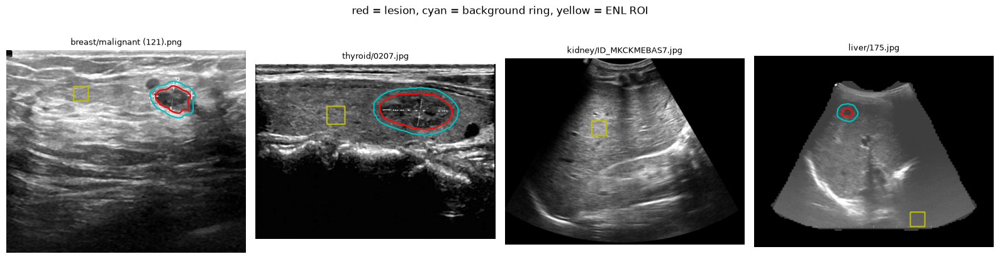

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, organ in zip(axes, ORGANS):
    s = next((s for s in datasets[organ] if s['mask'] is not None), datasets[organ][0])
    ax.imshow(s['clean'], cmap='gray', vmin=0, vmax=255); ax.axis('off'); ax.set_title(s['name'], fontsize=9)
    ax.contour(s['roi'], [0.5], colors='y')
    if s['mask'] is not None:
        ax.contour(lesion_ring(s['mask'], s['scan']), [0.5], colors='c'); ax.contour(s['mask'], [0.5], colors='r')
fig.suptitle('red = lesion, cyan = background ring, yellow = ENL ROI'); plt.tight_layout(); plt.show()

## 4. Despeckle filters
All filters share one signature: `f(img, scan_mask, **params) -> uint8`. The filter runs on the whole image and
`finish` keeps the result only inside the scan mask (outside stays 0). Defaults are the function defaults;
Noise σ for NLM, Wavelet and BM3D = median 7×7 local std in the scan (`skimage.estimate_sigma`
was tried first but barely changed the image: it underestimates correlated speckle). `GRIDS` holds 3-5 values of each method's main parameter for tuning in Step 5.

| Method | Idea | Main parameter |
|---|---|---|
| Median | rank filter | kernel `k` |
| Lee | local MMSE, weight = 1 − Cu²/Ci² (Cu = median local CoV) | window `k` |
| SRAD | speckle-reducing anisotropic diffusion (Yu & Acton), q0 = median of q | iterations `n_iter` |
| NLM | skimage `denoise_nl_means`, σ = `noise_sigma` | `h` (× σ) |
| Wavelet | `denoise_wavelet` BayesShrink soft threshold on log(1+img) | threshold scale `scale` |
| OBNLM | pixel-wise Bayesian NLM with Pearson distance (Coupé 2009), vectorized over search offsets | `h` |
| BM3D | `bm3d` package on log(1+img), σ = `noise_sigma` | σ scale `scale` |
| Guided | self-guided filter (He et al.) with box filters | `eps` |
| Bilateral | `cv2.bilateralFilter` | `sigma_color` |
| TV | `denoise_tv_chambolle` | `weight` |

In [14]:
from skimage.restoration import denoise_nl_means, denoise_wavelet, denoise_tv_chambolle
import bm3d as bm3d_lib

def finish(out, img, scan):
    out = np.clip(np.round(out), 0, 255).astype(np.uint8)
    out[~scan] = img[~scan]
    return out

def noise_sigma(f, scan, k=7):                                          # speckle is correlated, so wavelet-MAD
    mu = cv2.blur(f, (k, k))                                            # (estimate_sigma) underestimates it;
    sd = np.sqrt(np.maximum(cv2.blur(f * f, (k, k)) - mu * mu, 0))      # use the median local std instead
    return float(np.median(sd[cv2.erode(scan.astype(np.uint8), kernel(k)) > 0]))

def median(img, scan, k=5):
    return finish(cv2.medianBlur(img, k), img, scan)

def lee(img, scan, k=7):
    f = img.astype(np.float32)
    mu = cv2.blur(f, (k, k)); var = np.maximum(cv2.blur(f * f, (k, k)) - mu * mu, 0)
    ci2 = var / np.maximum(mu * mu, 1)
    cu2 = np.median(ci2[scan & (mu > 10)])                              # noise CoV² = typical local CoV²
    w = np.clip(1 - cu2 / np.maximum(ci2, 1e-6), 0, 1)
    return finish(mu + w * (f - mu), img, scan)

def srad(img, scan, n_iter=50, dt=0.1):
    I = img.astype(np.float32) / 255 + 1e-3
    for _ in range(n_iter):
        P = np.pad(I, 1, mode='edge')
        dN, dS, dW, dE = P[:-2, 1:-1] - I, P[2:, 1:-1] - I, P[1:-1, :-2] - I, P[1:-1, 2:] - I
        g2 = (dN ** 2 + dS ** 2 + dW ** 2 + dE ** 2) / I ** 2
        lap = (dN + dS + dW + dE) / I
        q2 = np.maximum((0.5 * g2 - lap ** 2 / 16) / (1 + lap / 4) ** 2, 0)
        q02 = np.median(q2[scan])                                        # speckle scale from the image itself
        c = np.clip(1 / (1 + (q2 - q02) / (q02 * (1 + q02) + 1e-12)), 0, 1)
        C = np.pad(c, 1, mode='edge')
        I = I + dt / 4 * (C[2:, 1:-1] * dS + c * dN + C[1:-1, 2:] * dE + c * dW)
    return finish(255 * (I - 1e-3), img, scan)

def nlm(img, scan, h=0.8, patch=5, dist=6):
    f = img.astype(np.float32) / 255
    sigma = noise_sigma(f, scan)
    out = denoise_nl_means(f, h=h * sigma, sigma=sigma, patch_size=patch, patch_distance=dist, fast_mode=True)
    return finish(255 * out, img, scan)

def wavelet(img, scan, scale=1.0, wavelet_name='db4', levels=4):
    L = np.log1p(img.astype(np.float32)); m = L.max()
    sigma = scale * noise_sigma(L / m, scan)
    out = denoise_wavelet(L / m, sigma=sigma, wavelet=wavelet_name, mode='soft', method='BayesShrink',
                          wavelet_levels=levels)
    return finish(np.expm1(out * m), img, scan)

def obnlm(img, scan, h=1.0, patch=5, search=11):
    f = img.astype(np.float32) + 1; H, W = f.shape; r = search // 2
    pad = cv2.copyMakeBorder(f, r, r, r, r, cv2.BORDER_REFLECT)
    num, den = np.zeros_like(f), np.zeros_like(f)
    mu = cv2.blur(f, (patch, patch)); var = np.maximum(cv2.blur(f * f, (patch, patch)) - mu * mu, 0)
    h2 = h * 2 * np.median((var / mu)[scan])                           # Pearson distance of two pure-speckle patches ~ 2·var/mean
    for dy in range(-r, r + 1):
        for dx in range(-r, r + 1):
            g = pad[r + dy: r + dy + H, r + dx: r + dx + W]
            d = cv2.blur((f - g) ** 2 / g, (patch, patch))                 # Pearson distance, averaged over patch
            w = np.exp(-d / h2)
            num += w * g; den += w
    return finish(num / den - 1, img, scan)

def bm3d_log(img, scan, scale=1.0):
    L = np.log1p(img.astype(np.float32)); m = L.max()
    out = bm3d_lib.bm3d(L / m, sigma_psd=scale * noise_sigma(L / m, scan))
    return finish(np.expm1(out * m), img, scan)

def guided(img, scan, r=4, eps=0.01, guide=None):                      # guide=None -> self-guided
    I = img.astype(np.float32) / 255; G = I if guide is None else guide.astype(np.float32) / 255
    box = lambda x: cv2.blur(x, (2 * r + 1, 2 * r + 1))
    mI, mG = box(I), box(G); cov = box(G * I) - mG * mI; var = box(G * G) - mG * mG
    a = cov / (var + eps); b = mI - a * mG
    return finish(255 * (box(a) * G + box(b)), img, scan)

def bilateral(img, scan, sigma_color=40, sigma_space=5, d=9):
    return finish(cv2.bilateralFilter(img, d, sigma_color, sigma_space), img, scan)

def tv(img, scan, weight=0.1):
    return finish(255 * denoise_tv_chambolle(img.astype(np.float32) / 255, weight=weight), img, scan)

FILTERS = {'Median': median, 'Lee': lee, 'SRAD': srad, 'NLM': nlm, 'Wavelet': wavelet, 'OBNLM': obnlm,
           'BM3D': bm3d_log, 'Guided': guided, 'Bilateral': bilateral, 'TV': tv}
GRIDS = {'Median': {'k': [3, 5, 7, 9]}, 'Lee': {'k': [5, 7, 9, 11]}, 'SRAD': {'n_iter': [20, 50, 100, 200]},
         'NLM': {'h': [0.6, 0.8, 1.0, 1.3]}, 'Wavelet': {'scale': [0.5, 1.0, 2.0, 3.0]},
         'OBNLM': {'h': [0.5, 1.0, 2.0, 4.0]}, 'BM3D': {'scale': [0.5, 1.0, 2.0, 3.0]},
         'Guided': {'eps': [0.001, 0.005, 0.01, 0.03]}, 'Bilateral': {'sigma_color': [20, 40, 60, 90]},
         'TV': {'weight': [0.05, 0.1, 0.2, 0.3]}}

breast/malignant (121).png (434, 512), default params (single image, no tuning)
organ    input                  ENL              SI             CNR            gCNR            Edge              ms
breast   prepared    127.93 ±  0.00    0.19 ±  0.00    1.21 ±  0.00    0.65 ±  0.00  120.58 ±  0.00   23.52 ±  0.00
breast   Median      241.34 ±  0.00    0.14 ±  0.00    1.30 ±  0.00    0.67 ±  0.00   95.72 ±  0.00    0.45 ±  0.00
breast   Lee         458.95 ±  0.00    0.15 ±  0.00    1.29 ±  0.00    0.67 ±  0.00   96.44 ±  0.00    3.20 ±  0.00
breast   SRAD        268.67 ±  0.00    0.17 ±  0.00    1.25 ±  0.00    0.66 ±  0.00  106.61 ±  0.00  126.72 ±  0.00
breast   NLM         295.08 ±  0.00    0.11 ±  0.00    1.23 ±  0.00    0.66 ±  0.00  110.77 ±  0.00  170.99 ±  0.00
breast   Wavelet     164.72 ±  0.00    0.18 ±  0.00    1.26 ±  0.00    0.66 ±  0.00  105.61 ±  0.00   17.61 ±  0.00
breast   OBNLM       343.80 ±  0.00    0.13 ±  0.00    1.24 ±  0.00    0.66 ±  0.00  106.23 ±  0.00   94.12 

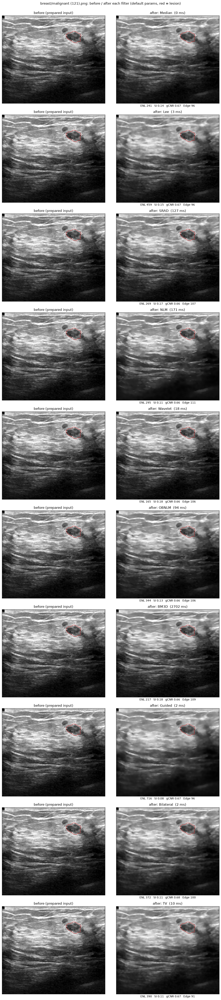

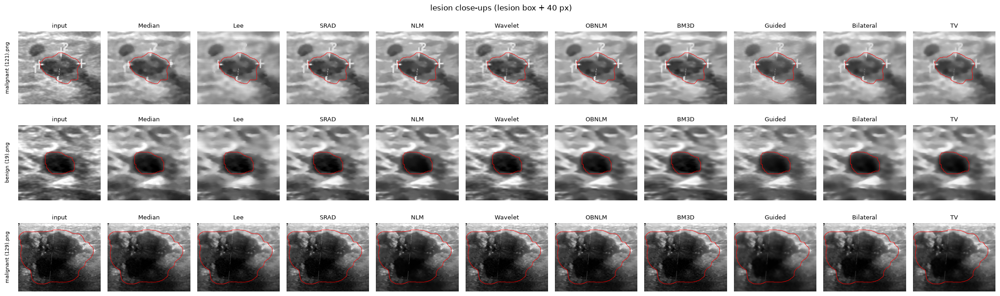

In [15]:
s = next(s for s in datasets['breast'] if s['mask'] is not None)
timed(bm3d_log, s['clean'], s['scan'])                                   # warm-up (first call imports/compiles)
outs, rows = {}, {('breast', 'prepared'): [s['base']]}
for name, fn in FILTERS.items():
    outs[name], ms = timed(fn, s['clean'], s['scan'])
    rows[('breast', name)] = [metrics(outs[name], s, ms)]
table(rows, f"{s['name']} {s['clean'].shape}, default params (single image, no tuning)")
slow = [n for n in FILTERS if rows[('breast', n)][0]['ms'] > 5000]
print('methods over 5 s per image:', slow or 'none')

fig, axes = plt.subplots(len(FILTERS), 2, figsize=(12, 5 * len(FILTERS)))   # one row per filter: before | after
for row, (name, out) in zip(axes, outs.items()):
    r = rows[('breast', name)][0]
    for ax, im, t in zip(row, [s['clean'], out], ['before (prepared input)', f"after: {name}  ({r['ms']:.0f} ms)"]):
        ax.imshow(im, cmap='gray', vmin=0, vmax=255); ax.contour(s['mask'], [0.5], colors='r', linewidths=0.6)
        ax.set_title(t, fontsize=12); ax.set_xticks([]); ax.set_yticks([])
    row[1].set_xlabel(f"ENL {r['ENL']:.0f}   SI {r['SI']:.2f}   gCNR {r['gCNR']:.2f}   Edge {r['Edge']:.0f}", fontsize=10)
fig.suptitle(f"{s['name']}: before / after each filter (default params, red = lesion)", y=1.0)
plt.tight_layout(); plt.show()

zoom = [x for x in datasets['breast'] if x['mask'] is not None][:3]     # lesion close-ups, 3 breast images
fig, axes = plt.subplots(len(zoom), 11, figsize=(22, 2.3 * len(zoom)))
for row, z in zip(axes, zoom):
    ys, xs = np.nonzero(z['mask']); pad = 40
    y0, y1, x0, x1 = max(ys.min() - pad, 0), ys.max() + pad, max(xs.min() - pad, 0), xs.max() + pad
    ims = [('input', z['clean'])] + [(n, fn(z['clean'], z['scan'])) for n, fn in FILTERS.items()]
    for ax, (name, im) in zip(row, ims):
        ax.imshow(im[y0:y1, x0:x1], cmap='gray', vmin=0, vmax=255); ax.axis('off')
        ax.contour(z['mask'][y0:y1, x0:x1], [0.5], colors='r', linewidths=0.6); ax.set_title(name, fontsize=9)
    row[0].text(-0.1, 0.5, z['name'].split('/')[1], transform=row[0].transAxes, rotation=90, va='center', ha='right', fontsize=8)
fig.suptitle('lesion close-ups (lesion box + 40 px)'); plt.tight_layout(); plt.show()

## 5. Comparison on breast (BUSI)
- The 20 breast images are split once with the fixed seed: 10 **tune**, 10 **test**.
- `tune(method, grid, tune_set)`: try every value in the method's grid on the tune set and keep the one with the
  highest mean CNR, subject to the rule **mean edge ratio ≥ 0.90**. Edge ratio = edge sharpness after filtering ÷
  edge sharpness of the raw input (the prepared image, see Step 3). If no value passes, the value with the highest
  edge ratio is kept and the method is flagged `rule = no`.
- `evaluate(method, params, test_set)`: metrics on the 10 test images only, as mean ± std.
- Methods are ranked by test gCNR; the "best" is the top-ranked method that passes the edge rule.

In [16]:
EDGE_MIN = 0.90
breast = [s for s in datasets['breast'] if s['mask'] is not None]
order = np.random.default_rng(SEED).permutation(len(breast))
tune_set, test_set = [breast[i] for i in order[:10]], [breast[i] for i in order[10:20]]

def run_method(method, params, data):
    res = []
    for s in data:
        out, ms = timed(FILTERS[method], s['clean'], s['scan'], **params)
        r = metrics(out, s, ms); r['EdgeRatio'] = r['Edge'] / s['base']['Edge']
        res.append(r)
    return res

def tune(method, grid, tune_set):
    (p, values), = grid.items()
    log = []                                                      # (value, mean CNR, mean edge ratio)
    for v in values:
        res = run_method(method, {p: v}, tune_set)
        log.append((v, np.mean([r['CNR'] for r in res]), np.mean([r['EdgeRatio'] for r in res])))
    ok = [l for l in log if l[2] >= EDGE_MIN]
    best = max(ok, key=lambda l: l[1]) if ok else max(log, key=lambda l: l[2])
    return {p: best[0]}, bool(ok), log

def evaluate(method, params, test_set):
    res = run_method(method, params, test_set)
    return {m: np.array([r[m] for r in res]) for m in res[0]}

tuned, results = {}, {}
for name in FILTERS:
    params, ok, log = tune(name, GRIDS[name], tune_set)
    tuned[name] = (params, ok)
    print(f"{name:9s} " + '  '.join(f"{v}: CNR {c:.3f} edge {e:.2f}" for v, c, e in log) + f"  -> {params} rule {'ok' if ok else 'FAILED'}")
    results[name] = evaluate(name, params, test_set)

Median    3: CNR 0.910 edge 0.90  5: CNR 0.927 edge 0.76  7: CNR 0.942 edge 0.67  9: CNR 0.956 edge 0.60  -> {'k': 3} rule FAILED


Lee       5: CNR 0.924 edge 0.79  7: CNR 0.933 edge 0.72  9: CNR 0.941 edge 0.69  11: CNR 0.946 edge 0.66  -> {'k': 5} rule FAILED


SRAD      20: CNR 0.910 edge 0.89  50: CNR 0.916 edge 0.81  100: CNR 0.921 edge 0.76  200: CNR 0.927 edge 0.72  -> {'n_iter': 20} rule FAILED


NLM       0.6: CNR 0.916 edge 0.84  0.8: CNR 0.918 edge 0.82  1.0: CNR 0.920 edge 0.81  1.3: CNR 0.924 edge 0.78  -> {'h': 0.6} rule FAILED


Wavelet   0.5: CNR 0.905 edge 0.97  1.0: CNR 0.910 edge 0.93  2.0: CNR 0.923 edge 0.86  3.0: CNR 0.935 edge 0.81  -> {'scale': 1.0} rule ok


OBNLM     0.5: CNR 0.915 edge 0.85  1.0: CNR 0.924 edge 0.80  2.0: CNR 0.933 edge 0.74  4.0: CNR 0.940 edge 0.68  -> {'h': 0.5} rule FAILED


BM3D      0.5: CNR 0.905 edge 0.94  1.0: CNR 0.912 edge 0.88  2.0: CNR 0.923 edge 0.80  3.0: CNR 0.932 edge 0.74  -> {'scale': 0.5} rule ok


Guided    0.001: CNR 0.911 edge 0.91  0.005: CNR 0.929 edge 0.76  0.01: CNR 0.941 edge 0.69  0.03: CNR 0.959 edge 0.58  -> {'eps': 0.001} rule ok


Bilateral 20: CNR 0.917 edge 0.80  40: CNR 0.932 edge 0.71  60: CNR 0.941 edge 0.67  90: CNR 0.948 edge 0.65  -> {'sigma_color': 20} rule FAILED


TV        0.05: CNR 0.927 edge 0.75  0.1: CNR 0.938 edge 0.69  0.2: CNR 0.956 edge 0.58  0.3: CNR 0.967 edge 0.52  -> {'weight': 0.05} rule FAILED


In [17]:
cols = ['ENL', 'SI', 'CNR', 'gCNR', 'EdgeRatio', 'ms']
base = {m: np.array([s['base'][m] if m != 'EdgeRatio' else 1.0 for s in test_set]) for m in cols[:-1]}
rank = sorted(FILTERS, key=lambda n: -results[n]['gCNR'].mean())
print(f"Test set (10 breast images), mean ± std, sorted by gCNR. Edge rule: tune-set edge ratio ≥ {EDGE_MIN}.")
print(f"{'method':10s} {'params':20s} {'rule':5s}" + ''.join(f'{c:>16s}' for c in cols))
print(f"{'prepared':10s} {'(no filter)':20s} {'-':5s}" + ''.join(f'{base[c].mean():8.2f} ± {base[c].std():5.2f}' for c in cols[:-1]) + f'{"-":>16s}')
for n in rank:
    params, ok = tuned[n]
    print(f"{n:10s} {str(params):20s} {'ok' if ok else 'NO':5s}" +
          ''.join(f'{results[n][c].mean():8.2f} ± {results[n][c].std():5.2f}' for c in cols))
passing = [n for n in rank if tuned[n][1]]
top3 = passing[:3]
print('\nmethods that fail the edge rule:', [n for n in rank if not tuned[n][1]] or 'none')
print('top 3 by test gCNR (edge rule passed):', top3)

Test set (10 breast images), mean ± std, sorted by gCNR. Edge rule: tune-set edge ratio ≥ 0.9.
method     params               rule              ENL              SI             CNR            gCNR       EdgeRatio              ms
prepared   (no filter)          -      159.00 ± 132.28    0.22 ±  0.06    1.12 ±  0.39    0.61 ±  0.14    1.00 ±  0.00               -
NLM        {'h': 0.6}           NO     635.40 ± 522.24    0.13 ±  0.03    1.14 ±  0.39    0.64 ±  0.12    0.87 ±  0.10  173.63 ± 38.42
Bilateral  {'sigma_color': 20}  NO     493.82 ± 408.60    0.13 ±  0.03    1.14 ±  0.38    0.63 ±  0.13    0.82 ±  0.13    1.48 ±  0.14
TV         {'weight': 0.05}     NO     587.45 ± 547.54    0.13 ±  0.03    1.16 ±  0.38    0.63 ±  0.13    0.80 ±  0.10   14.86 ±  8.97
OBNLM      {'h': 0.5}           NO     503.17 ± 520.55    0.17 ±  0.04    1.14 ±  0.39    0.63 ±  0.13    0.87 ±  0.10   85.18 ±  9.62
Guided     {'eps': 0.001}       ok     395.67 ± 321.13    0.14 ±  0.03    1.14 ±  0.39    0.63 ±

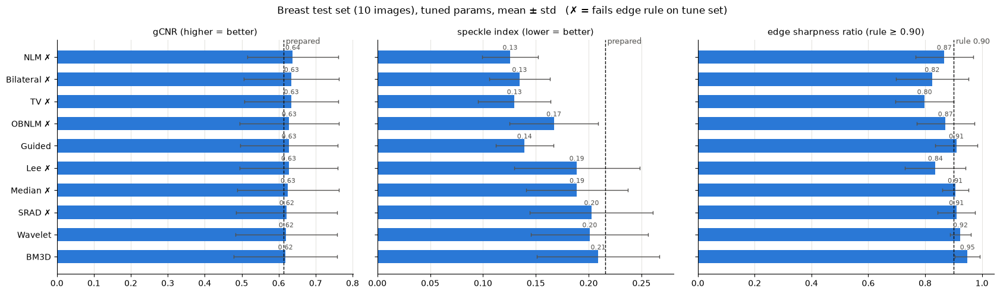

In [18]:
BLUE, INK, MUTED = '#2a78d6', '#0b0b0b', '#52514e'
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
y = np.arange(len(rank))[::-1]                                    # best gCNR at the top, same order in all three
for ax, m, title, ref, ref_label in [
        (axes[0], 'gCNR', 'gCNR (higher = better)', base['gCNR'].mean(), 'prepared'),
        (axes[1], 'SI', 'speckle index (lower = better)', base['SI'].mean(), 'prepared'),
        (axes[2], 'EdgeRatio', 'edge sharpness ratio (rule ≥ 0.90)', EDGE_MIN, 'rule 0.90')]:
    mean = [results[n][m].mean() for n in rank]; std = [results[n][m].std() for n in rank]
    ax.barh(y, mean, height=0.6, color=BLUE, xerr=std, error_kw=dict(ecolor=MUTED, lw=1, capsize=2))
    ax.axvline(ref, color=INK, ls='--', lw=1); ax.text(ref, len(rank) - 0.4, f' {ref_label}', color=MUTED, fontsize=9)
    for yi, v in zip(y, mean): ax.text(v, yi + 0.33, f'{v:.2f}', fontsize=8, color=MUTED, ha='center')
    ax.set_title(title, fontsize=11); ax.grid(axis='x', color='#e5e4e0', lw=0.8); ax.set_axisbelow(True)
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
axes[0].set_yticks(y); axes[0].set_yticklabels([n + ('' if tuned[n][1] else ' ✗') for n in rank])
fig.suptitle('Breast test set (10 images), tuned params, mean ± std   (✗ = fails edge rule on tune set)')
plt.tight_layout(); plt.show()

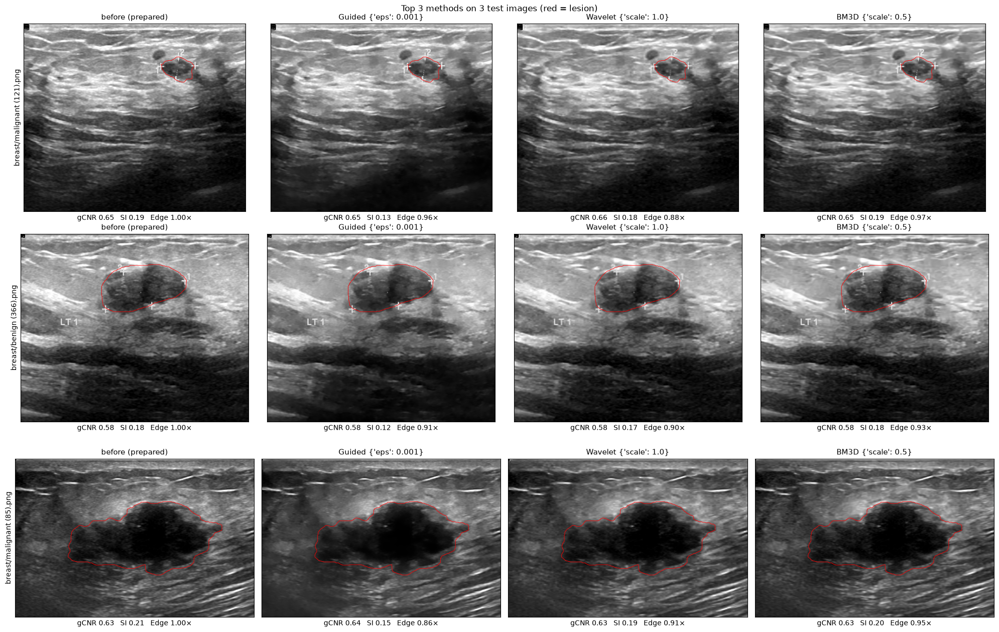

In [19]:
show = test_set[:3]
fig, axes = plt.subplots(len(show), 1 + len(top3), figsize=(5 * (1 + len(top3)), 4.3 * len(show)))
for row, s in zip(axes, show):
    ims = [('before (prepared)', s['clean'], s['base'])] + \
          [(f'{n} {tuned[n][0]}', out, metrics(out, s)) for n in top3 for out in [FILTERS[n](s['clean'], s['scan'], **tuned[n][0])]]
    for ax, (t, im, r) in zip(row, ims):
        ax.imshow(im, cmap='gray', vmin=0, vmax=255); ax.contour(s['mask'], [0.5], colors='r', linewidths=0.6)
        ax.set_title(t, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(f"gCNR {r['gCNR']:.2f}   SI {r['SI']:.2f}   Edge {r['Edge'] / s['base']['Edge']:.2f}×", fontsize=10)
    row[0].set_ylabel(s['name'], fontsize=10)
fig.suptitle('Top 3 methods on 3 test images (red = lesion)'); plt.tight_layout(); plt.show()

## 6. Improvements
Everything is chosen on the 10 breast **tune** images and reported on the 10 **test** images, as in Step 5.
- **Hybrid.** Step 5's top two methods are Guided and Wavelet, so two combinations are tried (Wavelet at its tuned scale, `eps` tuned):
  `Hybrid-seq` = Wavelet, then Guided; `Hybrid-joint` = Guided filter of the image using the Wavelet result as the guide
  (edges are taken from the less noisy guide). The final method `BEST` is picked by **tune-set CNR** among methods that pass the
  edge rule, never by test results.
- **`enhance(img, mask)`**: CLAHE (clip 2, 8×8 tiles), then sharpening of the **guided-filter base layer only**:
  `out = clahe + amount · (base − Gaussian(base))`. The base is speckle-free, so only real edges are boosted.
  `clip=0` skips CLAHE (sharpening only); clip 0 / 1 / 2 are compared to see which part helps or hurts.
- **`estimate_noise(img, scan_mask)`**: median local CoV (7×7 std / mean) over the 20 % most homogeneous parts of the scan
  (least structure after 9×9 smoothing, no dark shadow).
- **`auto_params(noise_level)`**: for each tune image, the largest-CNR `eps` that keeps that image's edge ratio ≥ 0.90;
  then a straight line log(eps) = a + b·log(noise) is fitted over the 10 tune images.

In [20]:
def show_table(rows, title):
    print(title); print(f"{'method':22s} {'params':18s} {'rule':5s}" + ''.join(f'{c:>16s}' for c in cols))
    for label, (params, ok, res) in rows.items():
        print(f"{label:22s} {params:18s} {ok:5s}" +
              ''.join(f'{res[c].mean():8.2f} ± {res[c].std():5.2f}' if c in res else f'{"-":>16s}' for c in cols))

fmt = lambda p: ', '.join(f'{k} {v:g}' for k, v in p.items())
wav = tuned['Wavelet'][0]
FILTERS['Hybrid-seq'] = lambda img, scan, eps=0.001: guided(wavelet(img, scan, **wav), scan, eps=eps)
FILTERS['Hybrid-joint'] = lambda img, scan, eps=0.001: guided(img, scan, eps=eps, guide=wavelet(img, scan, **wav))
HYB_GRID = {'eps': [0.0005, 0.001, 0.002, 0.005]}
tune_log = {}

tune_cnr = {'Guided': next(c for v, c, e in tune('Guided', GRIDS['Guided'], tune_set)[2] if v == tuned['Guided'][0]['eps'])}
for n in ['Hybrid-seq', 'Hybrid-joint']:
    params, ok, log = tune(n, HYB_GRID, tune_set)
    print(f"{n:12s} " + '  '.join(f"{v}: CNR {c:.3f} edge {e:.2f}" for v, c, e in log) + f"  -> {params} rule {'ok' if ok else 'FAILED'}")
    tuned[n] = (params, ok); tune_log[n] = log; results[n] = evaluate(n, params, test_set)
    if ok: tune_cnr[n] = next(c for v, c, e in log if v == params['eps'])
BEST = max(tune_cnr, key=tune_cnr.get)
print(f"\ntune-set CNR: {', '.join(f'{k} {v:.3f}' for k, v in tune_cnr.items())}  ->  BEST = {BEST}\n")
show_table({'prepared (no filter)': ('-', '-', base)} |
           {n: (fmt(tuned[n][0]), 'ok' if tuned[n][1] else 'NO', results[n]) for n in ['Guided', 'Hybrid-seq', 'Hybrid-joint']},
           'Hybrid vs single best, breast test set (10 images), mean ± std')

Hybrid-seq   0.0005: CNR 0.916 edge 0.88  0.001: CNR 0.920 edge 0.85  0.002: CNR 0.925 edge 0.81  0.005: CNR 0.936 edge 0.73  -> {'eps': 0.0005} rule FAILED


Hybrid-joint 0.0005: CNR 0.912 edge 0.90  0.001: CNR 0.916 edge 0.86  0.002: CNR 0.922 edge 0.82  0.005: CNR 0.934 edge 0.74  -> {'eps': 0.0005} rule FAILED

tune-set CNR: Guided 0.911  ->  BEST = Guided

Hybrid vs single best, breast test set (10 images), mean ± std
method                 params             rule              ENL              SI             CNR            gCNR       EdgeRatio              ms
prepared (no filter)   -                  -      159.00 ± 132.28    0.22 ±  0.06    1.12 ±  0.39    0.61 ±  0.14    1.00 ±  0.00               -
Guided                 eps 0.001          ok     395.67 ± 321.13    0.14 ±  0.03    1.14 ±  0.39    0.63 ±  0.13    0.91 ±  0.07    3.23 ±  0.48
Hybrid-seq             eps 0.0005         NO     429.53 ± 378.80    0.14 ±  0.03    1.15 ±  0.38    0.63 ±  0.13    0.88 ±  0.07   12.25 ±  1.10
Hybrid-joint           eps 0.0005         NO     379.55 ± 329.99    0.15 ±  0.03    1.14 ±  0.38    0.63 ±  0.13    0.89 ±  0.06   11.86 ±  1.10


In [21]:
def enhance(img, mask, clip=2.0, amount=1.0, sigma=2.0):
    out = (cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8)).apply(img) if clip > 0 else img).astype(np.float32)   # clip 0 = no CLAHE
    base = guided(out.astype(np.uint8), mask, r=4, eps=0.01).astype(np.float32)   # edges without speckle
    return finish(out + amount * (base - cv2.GaussianBlur(base, (0, 0), sigma)), img, mask)

FILTERS['Enhance only'] = lambda img, scan: enhance(img, scan)
FILTERS[f'{BEST} + enhance'] = lambda img, scan, **p: enhance(FILTERS[BEST](img, scan, **p), scan)
for n, p in [('Enhance only', {}), (f'{BEST} + enhance', tuned[BEST][0])]:
    results[n] = evaluate(n, p, test_set)
show_table({'prepared (no filter)': ('-', '-', base),
            'Enhance only': ('-', '-', results['Enhance only']),
            BEST: (fmt(tuned[BEST][0]), '', results[BEST]),
            f'{BEST} + enhance': (fmt(tuned[BEST][0]), '', results[f'{BEST} + enhance'])},
           'Without / with enhance(), breast test set (10 images), mean ± std')

for clip in [0, 1.0, 2.0]:                                        # which part hurts: CLAHE or the sharpening?
    FILTERS[f'{BEST} + enh clip {clip:g}'] = lambda img, scan, c=clip: enhance(FILTERS[BEST](img, scan, **tuned[BEST][0]), scan, clip=c)
    results[f'{BEST} + enh clip {clip:g}'] = evaluate(f'{BEST} + enh clip {clip:g}', {}, test_set)
print()
show_table({BEST: (fmt(tuned[BEST][0]), '', results[BEST])} |
           {f'{BEST} + enh clip {c:g}': ('sharpen only' if c == 0 else f'CLAHE {c:g}', '', results[f'{BEST} + enh clip {c:g}']) for c in [0, 1.0, 2.0]},
           'enhance() variants on top of the best filter: CLAHE clip 0 (off) / 1 / 2, breast test set')

Without / with enhance(), breast test set (10 images), mean ± std
method                 params             rule              ENL              SI             CNR            gCNR       EdgeRatio              ms
prepared (no filter)   -                  -      159.00 ± 132.28    0.22 ±  0.06    1.12 ±  0.39    0.61 ±  0.14    1.00 ±  0.00               -
Enhance only           -                  -       21.92 ± 13.92    0.32 ±  0.03    1.01 ±  0.39    0.58 ±  0.17    1.66 ±  0.33    4.03 ±  1.30
Guided                 eps 0.001                 395.67 ± 321.13    0.14 ±  0.03    1.14 ±  0.39    0.63 ±  0.13    0.91 ±  0.07    3.23 ±  0.48
Guided + enhance       eps 0.001                  46.26 ± 33.18    0.24 ±  0.03    1.02 ±  0.38    0.60 ±  0.17    1.52 ±  0.26    6.19 ±  0.62



enhance() variants on top of the best filter: CLAHE clip 0 (off) / 1 / 2, breast test set
method                 params             rule              ENL              SI             CNR            gCNR       EdgeRatio              ms
Guided                 eps 0.001                 395.67 ± 321.13    0.14 ±  0.03    1.14 ±  0.39    0.63 ±  0.13    0.91 ±  0.07    3.23 ±  0.48
Guided + enh clip 0    sharpen only              347.41 ± 286.75    0.16 ±  0.03    1.09 ±  0.38    0.62 ±  0.14    1.09 ±  0.14    6.37 ±  1.32
Guided + enh clip 1    CLAHE 1                   104.85 ± 81.22    0.20 ±  0.03    1.06 ±  0.38    0.62 ±  0.15    1.32 ±  0.12    9.87 ±  9.35
Guided + enh clip 2    CLAHE 2                    46.26 ± 33.18    0.24 ±  0.03    1.02 ±  0.38    0.60 ±  0.17    1.52 ±  0.26    6.22 ±  0.61


In [22]:
def estimate_noise(img, scan_mask, k=7, w=31):
    f = img.astype(np.float32)
    mu = cv2.blur(f, (k, k)); cov = np.sqrt(np.maximum(cv2.blur(f * f, (k, k)) - mu * mu, 0)) / np.maximum(mu, 1)
    sm = cv2.blur(f, (9, 9)); mw = cv2.blur(sm, (w, w))
    structure = np.sqrt(np.maximum(cv2.blur(sm * sm, (w, w)) - mw * mw, 0)) / np.maximum(mw, 1)
    valid = (cv2.erode(scan_mask.astype(np.uint8), kernel(w)) > 0) & (mw > np.percentile(f[scan_mask], 25))
    homog = valid & (structure <= np.percentile(structure[valid], 20))
    return float(np.median(cov[homog]))

EPS_FINE = [0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01]
pts = []                                                          # (noise level, best eps) per tune image
for s in tune_set:
    ok = [(e, r['CNR']) for e in EPS_FINE for r in [metrics(FILTERS[BEST](s['clean'], s['scan'], eps=e), s)]
          if r['Edge'] >= EDGE_MIN * s['base']['Edge']]
    pts.append((estimate_noise(s['clean'], s['scan']), max(ok, key=lambda t: t[1])[0] if ok else EPS_FINE[0]))
ln, le = np.log(np.array(pts)).T
b, a = np.polyfit(ln, le, 1)

def auto_params(noise_level):
    return {'eps': float(np.clip(np.exp(a + b * np.log(noise_level)), EPS_FINE[0], EPS_FINE[-1]))}

print(f'fit on tune set: log(eps) = {a:.2f} + {b:.2f}·log(noise),  r = {np.corrcoef(ln, le)[0, 1]:.2f}')
print('tune images (noise, best eps):', ', '.join(f'({n:.3f}, {e:g})' for n, e in pts))
FILTERS[f'{BEST} auto'] = lambda img, scan: FILTERS[BEST](img, scan, **auto_params(estimate_noise(img, scan)))
results[f'{BEST} auto'] = evaluate(f'{BEST} auto', {}, test_set)
test_eps = [auto_params(estimate_noise(s['clean'], s['scan']))['eps'] for s in test_set]
print(f'auto eps on test images: {", ".join(f"{e:.4f}" for e in test_eps)}\n')
show_table({'prepared (no filter)': ('-', '-', base),
            f'{BEST} fixed': (fmt(tuned[BEST][0]), '', results[BEST]),
            f'{BEST} auto': ('eps from noise', '', results[f'{BEST} auto'])},
           'Fixed vs auto params, breast test set (10 images), mean ± std (auto ms includes estimate_noise)')

fit on tune set: log(eps) = -3.30 + 1.45·log(noise),  r = 0.54
tune images (noise, best eps): (0.108, 0.002), (0.078, 0.001), (0.050, 0.001), (0.062, 0.0002), (0.080, 0.002), (0.089, 0.002), (0.071, 0.0005), (0.055, 0.0005), (0.092, 0.001), (0.117, 0.001)
auto eps on test images: 0.0010, 0.0005, 0.0014, 0.0006, 0.0006, 0.0014, 0.0013, 0.0006, 0.0014, 0.0008

Fixed vs auto params, breast test set (10 images), mean ± std (auto ms includes estimate_noise)
method                 params             rule              ENL              SI             CNR            gCNR       EdgeRatio              ms
prepared (no filter)   -                  -      159.00 ± 132.28    0.22 ±  0.06    1.12 ±  0.39    0.61 ±  0.14    1.00 ±  0.00               -
Guided fixed           eps 0.001                 395.67 ± 321.13    0.14 ±  0.03    1.14 ±  0.39    0.63 ±  0.13    0.91 ±  0.07    3.23 ±  0.48
Guided auto            eps from noise            332.58 ± 217.42    0.14 ±  0.02    1.14 ±  0.39    0.63 ±  0

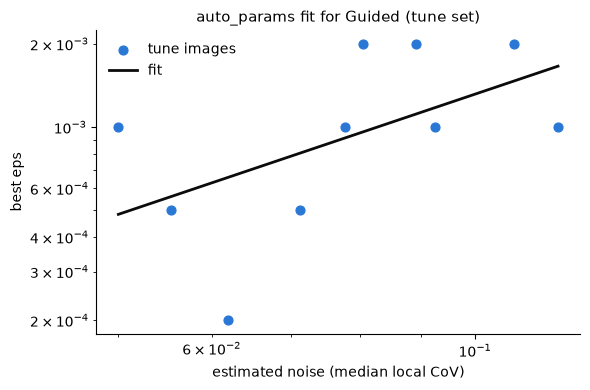

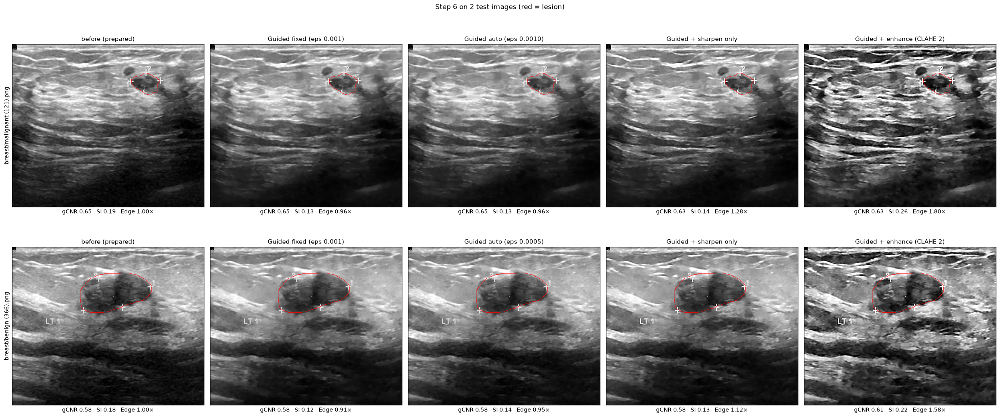

In [23]:
BLUE, INK, MUTED = '#2a78d6', '#0b0b0b', '#52514e'
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(*np.array(pts).T, s=40, color=BLUE, label='tune images')
xs = np.linspace(ln.min(), ln.max(), 50); ax.plot(np.exp(xs), np.exp(a + b * xs), color=INK, lw=2, label='fit')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('estimated noise (median local CoV)'); ax.set_ylabel('best eps')
ax.set_title(f'auto_params fit for {BEST} (tune set)', fontsize=11); ax.legend(frameon=False)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

show = test_set[:2]
fig, axes = plt.subplots(len(show), 5, figsize=(25, 5.6 * len(show)))
for row, s in zip(axes, show):
    ims = [('before (prepared)', s['clean']),
           (f'{BEST} fixed ({fmt(tuned[BEST][0])})', FILTERS[BEST](s['clean'], s['scan'], **tuned[BEST][0])),
           (f'{BEST} auto (eps {auto_params(estimate_noise(s["clean"], s["scan"]))["eps"]:.4f})', FILTERS[f'{BEST} auto'](s['clean'], s['scan'])),
           (f'{BEST} + sharpen only', FILTERS[f'{BEST} + enh clip 0'](s['clean'], s['scan'])),
           (f'{BEST} + enhance (CLAHE 2)', FILTERS[f'{BEST} + enhance'](s['clean'], s['scan'], **tuned[BEST][0]))]
    for ax, (t, im) in zip(row, ims):
        r = metrics(im, s)
        ax.imshow(im, cmap='gray', vmin=0, vmax=255); ax.contour(s['mask'], [0.5], colors='r', linewidths=0.6)
        ax.set_title(t, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(f"gCNR {r['gCNR']:.2f}   SI {r['SI']:.2f}   Edge {r['Edge'] / s['base']['Edge']:.2f}×", fontsize=10)
    row[0].set_ylabel(s['name'], fontsize=10)
fig.suptitle('Step 6 on 2 test images (red = lesion)'); plt.tight_layout(); plt.show()

## 7. Final pipeline on all organs (no re-tuning)
Everything was chosen on breast in Steps 5-6 and is reused unchanged: tuned parameters, the `auto_params` fit and
`ENH_CLIP = 0` (enhancement = guided base-layer sharpening only, since CLAHE brought speckle back in Step 6).
Breast = its 10 test images; thyroid, kidney, liver = all 20 images each. The fallback kidney set has no masks,
so only the speckle index and runtime exist there. Edge ratio is relative to the prepared (unfiltered) image.

`post_process(img, method="auto", enhance=False)`: prepare → estimate noise → auto params → despeckle → (enhance).

In [24]:
ENH_CLIP = 0
HYBRID = max(['Hybrid-seq', 'Hybrid-joint'], key=lambda n: next(e for v, c, e in tune_log[n] if v == tuned[n][0]['eps']))
FILTERS['Final (auto)'] = lambda img, scan: FILTERS[f'{BEST} auto'](img, scan)
FILTERS['Final + enhance'] = lambda img, scan: enhance(FILTERS['Final (auto)'](img, scan), scan, clip=ENH_CLIP)
FINAL_METHODS = {'prepared (no filter)': None, **{n: tuned[n][0] for n in top3}, HYBRID: tuned[HYBRID][0],
                 'Final (auto)': {}, 'Final + enhance': {}}

def run_organ(name, params, data):
    res = []
    for s in data:
        if params is None: r = dict(s['base'], ms=np.nan)
        else:
            out, ms = timed(FILTERS[name], s['clean'], s['scan'], **params); r = metrics(out, s, ms)
        if 'Edge' in r: r['EdgeRatio'] = r['Edge'] / s['base']['Edge']
        res.append(r)
    return {m: np.array([r.get(m, np.nan) for r in res]) for m in ['gCNR', 'SI', 'EdgeRatio', 'ms']}

organ_data = {'breast': test_set, 'thyroid': datasets['thyroid'], 'kidney': datasets['kidney'], 'liver': datasets['liver']}
final = {(o, n): run_organ(n, p, d) for o, d in organ_data.items() for n, p in FINAL_METHODS.items()}

cell_fmt = lambda v: f'{np.nanmean(v):6.2f} ± {np.nanstd(v):4.2f}' if np.isfinite(v).any() else 'n/a'
print(f"hybrid shown: {HYBRID}.  mean ± std; breast = 10 test images, other organs = 20 images, no re-tuning")
print(f"{'organ':8s} {'method':22s}" + ''.join(f'{c:>18s}' for c in ['gCNR', 'SI', 'EdgeRatio', 'ms']))
for (o, n), r in final.items():
    print(f"{o:8s} {n:22s}" + ''.join(f'{cell_fmt(r[c]):>18s}' for c in ['gCNR', 'SI', 'EdgeRatio', 'ms']))
    if n == 'Final + enhance': print()

print(f'auto_params was fitted on breast tune noise {min(n for n, _ in pts):.3f}-{max(n for n, _ in pts):.3f}; eps is clipped to {EPS_FINE[0]}-{EPS_FINE[-1]}')
for o, d in organ_data.items():
    nz = [estimate_noise(s['clean'], s['scan']) for s in d]; ep = [auto_params(n)['eps'] for n in nz]
    print(f'{o:8s} noise {np.mean(nz):.3f} ({min(nz):.3f}-{max(nz):.3f})   auto eps {np.mean(ep):.4f} ({min(ep):.4f}-{max(ep):.4f})')

hybrid shown: Hybrid-joint.  mean ± std; breast = 10 test images, other organs = 20 images, no re-tuning
organ    method                              gCNR                SI         EdgeRatio                ms
breast   prepared (no filter)         0.61 ± 0.14       0.22 ± 0.06       1.00 ± 0.00               n/a
breast   Guided                       0.63 ± 0.13       0.14 ± 0.03       0.91 ± 0.07       2.65 ± 0.26
breast   Wavelet                      0.62 ± 0.14       0.20 ± 0.06       0.92 ± 0.04       9.52 ± 0.92
breast   BM3D                         0.62 ± 0.14       0.21 ± 0.06       0.95 ± 0.04  3869.80 ± 503.74
breast   Hybrid-joint                 0.63 ± 0.13       0.15 ± 0.03       0.89 ± 0.06      17.81 ± 2.84
breast   Final (auto)                 0.63 ± 0.13       0.14 ± 0.02       0.92 ± 0.06      10.72 ± 1.33
breast   Final + enhance              0.62 ± 0.14       0.16 ± 0.03       1.11 ± 0.13      13.61 ± 1.48

thyroid  prepared (no filter)         0.44 ± 0.17       0.37 ±

kidney   noise 0.108 (0.072-0.188)   auto eps 0.0015 (0.0008-0.0033)
liver    noise 0.084 (0.023-0.112)   auto eps 0.0010 (0.0002-0.0016)


In [25]:
def post_process(img, method='auto', enhance=False):
    clean, scan = prepare(to_gray(img))
    params = auto_params(estimate_noise(clean, scan)) if method == 'auto' else tuned[method][0]
    out = FILTERS[BEST if method == 'auto' else method](clean, scan, **params)
    return sharpen(out, scan) if enhance else out

sharpen = lambda img, scan: enhance(img, scan, clip=ENH_CLIP)    # module-level enhance() (the argument shadows it)
for o in ORGANS:                                                  # check: same result as the pipeline above, and timing
    s = organ_data[o][0]
    out, ms = timed(post_process, s['image'])
    same = np.array_equal(out, FILTERS['Final (auto)'](s['clean'], s['scan']))
    print(f'{o:8s} {s["name"]:32s} post_process: {out.dtype} {out.shape}  {ms:6.1f} ms  identical to pipeline: {same}')

breast   breast/malignant (121).png       post_process: uint8 (434, 512)    46.7 ms  identical to pipeline: True


thyroid  thyroid/0207.jpg                 post_process: uint8 (302, 413)    22.8 ms  identical to pipeline: True
kidney   kidney/ID_MKCKMEBAS7.jpg         post_process: uint8 (399, 512)    25.1 ms  identical to pipeline: True
liver    liver/175.jpg                    post_process: uint8 (410, 512)    22.9 ms  identical to pipeline: True


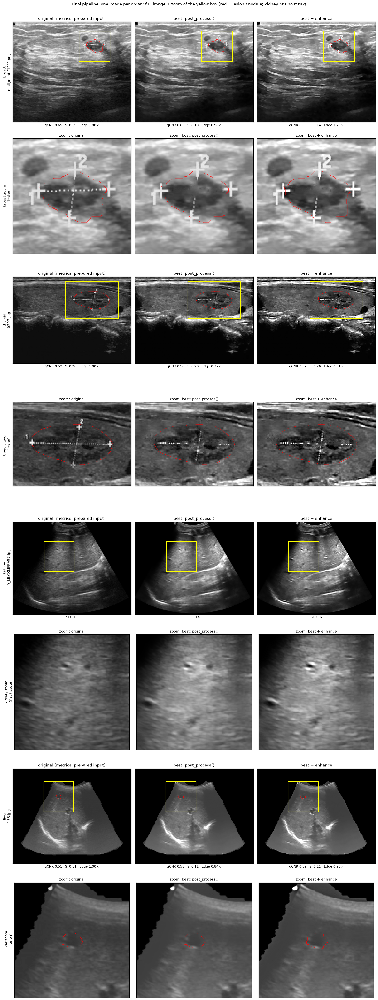

In [26]:
from matplotlib.patches import Rectangle

def zoom_box(s, size=130, pad=30):                               # lesion box + pad (kidney: ENL ROI), at least size px
    m = s['mask'] if s['mask'] is not None else s['roi']
    ys, xs = np.nonzero(m); cy, cx = (ys.min() + ys.max()) // 2, (xs.min() + xs.max()) // 2
    h, w = max(np.ptp(ys) + 2 * pad, size) // 2, max(np.ptp(xs) + 2 * pad, size) // 2
    return max(cy - h, 0), min(cy + h, m.shape[0]), max(cx - w, 0), min(cx + w, m.shape[1])

fig, axes = plt.subplots(8, 3, figsize=(16, 42))
for k, o in enumerate(ORGANS):
    s = next((x for x in organ_data[o] if x['mask'] is not None), organ_data[o][0])
    ims = [('original (metrics: prepared input)', s['image']), ('best: post_process()', post_process(s['image'])),
           ('best + enhance', post_process(s['image'], enhance=True))]
    y0, y1, x0, x1 = zoom_box(s)
    for ax, zax, (t, im) in zip(axes[2 * k], axes[2 * k + 1], ims):
        r = s['base'] if t.startswith('original') else metrics(im, s)
        lab = f"SI {r['SI']:.2f}"
        if s['mask'] is not None: lab = f"gCNR {r['gCNR']:.2f}   " + lab + f"   Edge {r['Edge'] / s['base']['Edge']:.2f}×"
        ax.imshow(im, cmap='gray', vmin=0, vmax=255); ax.set_title(t, fontsize=12); ax.set_xlabel(lab, fontsize=10)
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec='yellow', lw=1.5))
        zax.imshow(im[y0:y1, x0:x1], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        zax.set_title(f'zoom: {t.split(" (")[0]}', fontsize=11)
        for a_, m_ in [(ax, s['mask']), (zax, None if s['mask'] is None else s['mask'][y0:y1, x0:x1])]:
            if m_ is not None: a_.contour(m_, [0.5], colors='r', linewidths=0.6)
            a_.set_xticks([]); a_.set_yticks([])
    axes[2 * k, 0].set_ylabel(f'{o}\n{s["name"].split("/")[1]}', fontsize=11)
    axes[2 * k + 1, 0].set_ylabel(f'{o} zoom\n(' + ('lesion' if s['mask'] is not None else 'flat tissue') + ')', fontsize=11)
fig.suptitle('Final pipeline, one image per organ: full image + zoom of the yellow box (red = lesion / nodule; kidney has no mask)', y=1.0)
plt.tight_layout(); plt.show()

## Conclusion
**Best method: the guided filter** (self-guided, `eps` from `auto_params`; fixed `eps = 0.001` is almost identical).
On the 10 breast test images it lowers the speckle index from 0.22 to 0.14 (ENL about 2.5×), keeps 92 % of the lesion
edge sharpness and runs in about 10-20 ms per image including the noise estimate (runtimes vary between runs). It is the only one of the 10 methods that
clearly removes speckle *and* passes the 90 % edge rule on breast. Wavelet and BM3D also pass the rule, but they barely
remove speckle (SI 0.20 / 0.21), and BM3D takes 3-4 s per image. The hybrids, CLAHE and auto-tuning did not beat it (Step 6).

**Does it work on all organs (no re-tuning)?** Partly.
- *Speckle reduction transfers well:* SI drops on every organ (thyroid 0.37 → 0.23, kidney 0.20 → 0.13, liver 0.18 → 0.14).
- *Lesion contrast improves only a little everywhere:* gCNR +0.02 to +0.03 (breast 0.61 → 0.63, thyroid 0.44 → 0.47,
  liver 0.36 → 0.39). These gains are much smaller than the spread between images (std 0.13-0.17), so they are not
  significant with 10-20 images.
- *Edge preservation fails outside breast:* the edge ratio is 0.79 on thyroid and 0.83 on liver, below the 0.90 rule.

**Where it fails and why.**
- *Thyroid:* its images are noisier (estimated noise 0.150 on average, up to 0.260) than the breast images `auto_params`
  was fitted on (0.050-0.117). The fitted line is extrapolated, gives a larger `eps` and over-smooths: the fixed `eps`
  keeps more edge (0.88) than auto (0.79). Auto-tuning helps only inside the noise range it was fitted on.
- *Liver:* the noise level is like breast, but the edge ratio still drops to about 0.82 with any guided setting. The
  liver masses are small and low-contrast, so the thin border band is easily smoothed. Only BM3D keeps ≥ 0.90 on thyroid
  and liver, and it removes almost no speckle.
- `enhance=True` (guided base-layer sharpening, no CLAHE) brings the edge ratio back to about 1.0 on every organ
  (thyroid 0.98, liver 1.01) while keeping most of the speckle reduction (thyroid SI 0.29 vs 0.37 raw) and the same gCNR.
  For thyroid and liver it is the better trade-off; the default stays `enhance=False` as specified.

**Limitations.**
- Small data: 20 images per organ, one 10/10 breast split; no confidence intervals or significance tests.
- No clean ground truth: all metrics are no-reference or mask-based. The edge metric depends on mask accuracy, and the
  gCNR ring (10 px) may include other structures.
- Kidney uses the fallback Kaggle set without masks, so kidney has only SI and runtime; lesion contrast and edges are untested there.
- The `auto_params` fit is weak (r = 0.54 on 10 points) and is not reliable outside its noise range.
- Tuning grids start at fixed values: 7 of 10 methods failed the edge rule even at their mildest setting, so milder
  settings were not explored and those methods may be under-rated.
- The enhancement variant (sharpen only) was chosen after looking at the breast test results in Step 6, which is a
  small test-set leak.
- Annotation removal is imperfect: faint dotted calipers remain (e.g. inside the thyroid nodule above) and can bias metrics.
- Runtimes are from one Mac CPU and vary between runs.